In [3]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from matplotlib.legend import Legend

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "figures_notebooks" else Path.cwd()


In [16]:
# 68% CI unified CSVs: |α|=n_q (alpha_nq) vs |α|=n_q/2 (alpha_nq2)
_UNIFIED_CSV = "qvc_unified_eta_0p01_0p02_0p05_floor0p52_nhg1600_nml1600.csv"
CSV_RELAX_NQ = REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq" / "ci68_IT" / _UNIFIED_CSV
CSV_RELAX_NQ2 = REPO_ROOT / "curve_fitting" / "plots_newQ_alpha_nq2" / "ci68_IT" / _UNIFIED_CSV


def plot_fig1_relaxation_mf_onepanel(
    save_pdf=True,
    figsize=(4, 2.8),
):
    """
    Fig. 1: curve-fitting unified CSVs via plot_mf_onepanel_relaxation_p01.plot_onepanel
    (thermal relaxation p=0.1, η ∈ {1%, 5%}, device A only, readout 0.1%).

    Overlays |α|=n_q (red) and |α|=n_q/2 (green); legends: MF method, η, and |α|.
    Loads plotting module from disk so edits to the .py are picked up without restarting the kernel.
    """
    if not CSV_RELAX_NQ.is_file():
        raise FileNotFoundError(CSV_RELAX_NQ)
    if not CSV_RELAX_NQ2.is_file():
        raise FileNotFoundError(CSV_RELAX_NQ2)

    plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))

    _plot_py = REPO_ROOT / "curve_fitting" / "plot_mf_onepanel_relaxation_p01.py"
    _spec = importlib.util.spec_from_file_location(
        "plot_mf_onepanel_relaxation_p01_live",
        _plot_py,
    )
    _mf = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mf)
    _load_rows = _mf._load_rows
    plot_onepanel = _mf.plot_onepanel

    rows_nq = _load_rows(CSV_RELAX_NQ)
    rows_nq2 = _load_rows(CSV_RELAX_NQ2)
    fig, ax = plot_onepanel(
        rows_nq,
        channel="relaxation",
        amplitude=0.1,
        etas=[0.01, 0.05],
        devices=["A"],
        readout_error="0%",
        readout_by_device={"A": "0.1%"},
        out_png=None,
        out_pdf=None,
        figsize=figsize,
        close_fig=False,
        manuscript_fig1=True,
        manuscript_dual_alpha_rows={"nq": rows_nq, "nq2": rows_nq2},
    )
    if save_pdf:
        out = REPO_ROOT / "figures_manuscript" / "fig1.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        plt.tight_layout()
        fig.savefig(
            str(out)
        )
    plt.show()
    plt.close(fig)



Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


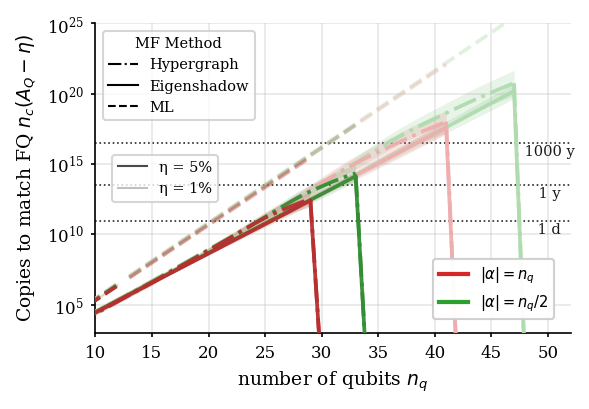

In [17]:
plot_fig1_relaxation_mf_onepanel(save_pdf=True)
